In [19]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

### 1. Load feature-engineered dataset

In [20]:
df = pd.read_csv("../../data/item_sales/processed_sales_features_v2.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,venue_id,sku_id,phl1_id,phl2_id,phl3_id,operating_minutes,country_id,price,promo_flag,...,lag_14,lag_28,rolling_7,rolling_14,rolling_28,weekday,weekend,stock_ratio,promo_price_interaction,lag1_stock_interaction
0,2025-09-06,V004,S0001,P1_01,P2_03,P3_009,900,FI,0.55,0,...,47.0,67.0,43.857143,44.642857,42.357143,5,1,1.0,0.0,58.0
1,2025-09-06,V005,S0001,P1_01,P2_03,P3_009,840,FI,0.55,0,...,43.0,39.0,47.285714,43.928571,41.285714,5,1,1.0,0.0,37.0
2,2025-09-07,V001,S0001,P1_01,P2_03,P3_009,900,FI,0.59,0,...,41.0,57.0,36.142857,42.000000,40.464286,6,1,0.0,0.0,0.0
3,2025-09-07,V002,S0001,P1_01,P2_03,P3_009,720,FI,0.59,0,...,39.0,61.0,31.857143,39.071429,38.428571,6,1,0.0,0.0,0.0
4,2025-09-07,V003,S0001,P1_01,P2_03,P3_009,900,FI,0.59,0,...,85.0,24.0,24.857143,36.285714,36.250000,6,1,0.0,0.0,0.0


### 2. Define features and target

In [21]:
features = [
    "lag_1",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_7",
    "rolling_14",
    "rolling_28",
    "promo_flag",
    "promo_depth",
    "stock_ratio",
    "price",
    "weekday",
    "weekend",
    "promo_price_interaction",
    "lag1_stock_interaction"
]

X = df[features]
y = df["units_sold"]

### Time-based train/test split

In [22]:
df = df.sort_values("date").reset_index(drop=True)

cutoff_date = df["date"].quantile(0.8)

train_idx = df["date"] <= cutoff_date
test_idx = df["date"] > cutoff_date

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test, y_test = X.loc[test_idx], y.loc[test_idx]

df.loc[train_idx, "date"].min(), df.loc[train_idx, "date"].max(), df.loc[test_idx, "date"].min(), df.loc[test_idx, "date"].max()

(Timestamp('2025-09-06 00:00:00'),
 Timestamp('2025-11-15 00:00:00'),
 Timestamp('2025-11-16 00:00:00'),
 Timestamp('2025-11-30 00:00:00'))

### Define evaluation metrics (MAE + MAPE)

In [23]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-9
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

### Model 0 — Baseline

In [24]:
y_pred_baseline = X_test["lag_1"]
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mape_baseline = mape(y_test, y_pred_baseline)

mae_baseline, mape_baseline

(0.8583703703703703, np.float64(23037037065.905643))

### Model 1 — Ridge Regression

In [25]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mape_ridge = mape(y_test, y_pred_ridge)

mae_ridge, mape_ridge

(2.068644699743858, np.float64(140245253168.88867))

### Model 2 — Random Forest

In [26]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = mape(y_test, y_pred_rf)

mae_rf, mape_rf

(0.5855884993134437, np.float64(17252831054.37094))

### Model 3—XGBoost model

In [27]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = mape(y_test, y_pred_xgb)

mae_xgb, mape_xgb

(0.5954710841178894, np.float64(17631512663.30856))

In [28]:
results = pd.DataFrame({
    "model": ["baseline_lag1", "ridge", "random_forest", "xgboost"],
    "MAE": [mae_baseline, mae_ridge, mae_rf, mae_xgb],
    "MAPE_%": [mape_baseline, mape_ridge, mape_rf, mape_xgb]
}).sort_values("MAE")

results

,model,MAE,MAPE_%
2,random_forest,0.585588,1.725283e+10
3,xgboost,0.595471,1.763151e+10
0,baseline_lag1,0.858370,2.303704e+10
1,ridge,2.068645,1.402453e+11


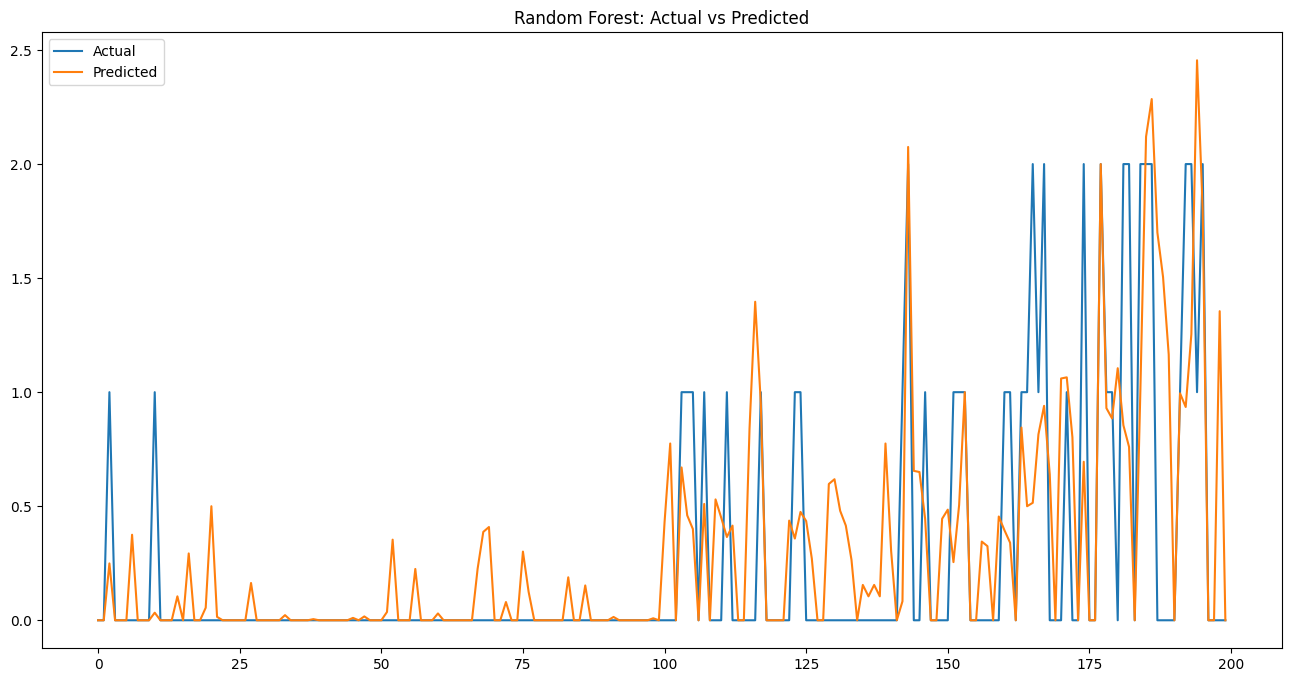

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_rf[:200], label="Predicted")
plt.legend()
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [30]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
15,lag1_stock_interaction,0.708923
7,rolling_28,0.081991
4,lag_28,0.031338
6,rolling_14,0.030431
1,lag_3,0.027210
5,rolling_7,0.025567
2,lag_7,0.023733
3,lag_14,0.020068
11,price,0.015255
0,lag_1,0.011753


In [31]:
importance_xgb = pd.DataFrame({
    "feature": features,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

importance_xgb

,feature,importance
15,lag1_stock_interaction,0.516294
10,stock_ratio,0.151217
6,rolling_14,0.098583
13,weekend,0.061020
7,rolling_28,0.032400
0,lag_1,0.031690
12,weekday,0.027243
4,lag_28,0.016172
5,rolling_7,0.012454
1,lag_3,0.012359


In [32]:
results.to_csv("../../reports/item_sales_model_results_v2.csv", index=False)

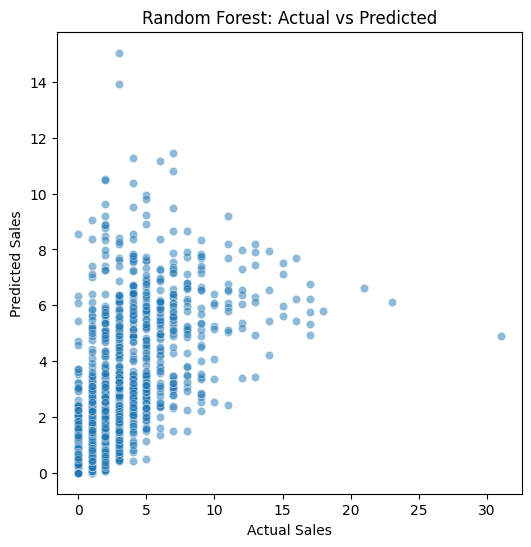

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

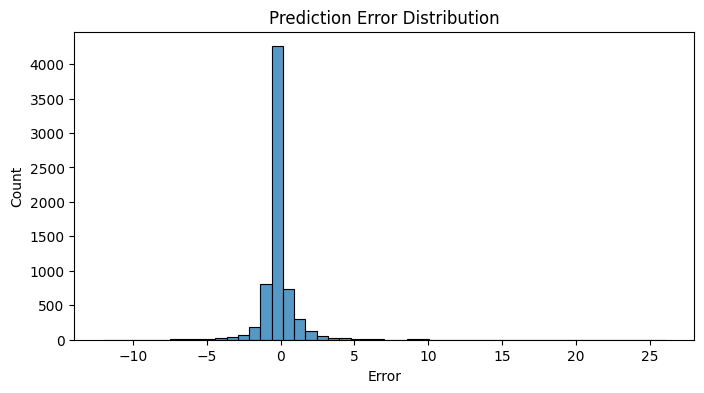

In [34]:
errors = y_test - y_pred_rf

plt.figure(figsize=(8,4))
sns.histplot(errors, bins=50)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

In [36]:
import joblib
import os

os.makedirs("../../models", exist_ok=True)

joblib.dump(rf, "../../models/random_forest_model.pkl")

['../../models/random_forest_model.pkl']